# Retail Sales Performance Analytics and Forecasting

## Objective
Analyze global retail sales data to identify business trends, evaluate profitability, understand customer behavior, and forecast future sales using Python and Power BI.

## Tools
- Python
- Pandas
- Matplotlib
- Power BI
- Google Colab
- GitHub


# Business Questions

1. Which market generates the highest sales?
2. Which products generate the highest profit?
3. How do discounts affect profitability?
4. Which customer segments are most valuable?
5. What are the monthly sales trends?
6. What will sales look like in the next 12 months?

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# ==========================================
# Import Required Libraries
# ==========================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
import os

os.listdir('/content/drive/MyDrive/Retail-Sales-Performance-Analytics-and-Forecasting')

['data',
 'notebooks',
 'dashboard',
 'docs',
 'reports',
 'images',
 'src',
 'presentation']

In [ ]:
os.listdir(
    '/content/drive/MyDrive/Retail-Sales-Performance-Analytics-and-Forecasting/data'
)

['raw', 'processed']

In [ ]:
os.listdir(
    '/content/drive/MyDrive/Retail-Sales-Performance-Analytics-and-Forecasting/data/raw'
)

['superstore.csv']

In [ ]:
# ==========================================
# Load Dataset
# ==========================================

df = pd.read_csv(
    '/content/drive/MyDrive/Retail-Sales-Performance-Analytics-and-Forecasting/data/raw/superstore.csv',
    encoding='latin1'
)

print("✅ Dataset loaded successfully!")

✅ Dataset loaded successfully!


In [ ]:
df.shape

(51290, 27)

In [ ]:
df.head()

,Category,City,Country,Customer.ID,Customer.Name,Discount,Market,è®°å½æ°,Order.Date,Order.ID,...,Sales,Segment,Ship.Date,Ship.Mode,Shipping.Cost,State,Sub.Category,Year,Market2,weeknum
0,Office Supplies,Los Angeles,United States,LS-172304,Lycoris Saunders,0.0,US,1,2011-01-07 00:00:00.000,CA-2011-130813,...,19,Consumer,2011-01-09 00:00:00.000,Second Class,4.37,California,Paper,2011,North America,2
1,Office Supplies,Los Angeles,United States,MV-174854,Mark Van Huff,0.0,US,1,2011-01-21 00:00:00.000,CA-2011-148614,...,19,Consumer,2011-01-26 00:00:00.000,Standard Class,0.94,California,Paper,2011,North America,4
2,Office Supplies,Los Angeles,United States,CS-121304,Chad Sievert,0.0,US,1,2011-08-05 00:00:00.000,CA-2011-118962,...,21,Consumer,2011-08-09 00:00:00.000,Standard Class,1.81,California,Paper,2011,North America,32
3,Office Supplies,Los Angeles,United States,CS-121304,Chad Sievert,0.0,US,1,2011-08-05 00:00:00.000,CA-2011-118962,...,111,Consumer,2011-08-09 00:00:00.000,Standard Class,4.59,California,Paper,2011,North America,32
4,Office Supplies,Los Angeles,United States,AP-109154,Arthur Prichep,0.0,US,1,2011-09-29 00:00:00.000,CA-2011-146969,...,6,Consumer,2011-10-03 00:00:00.000,Standard Class,1.32,California,Paper,2011,North America,40


In [ ]:
df.columns.tolist()

['Category',
 'City',
 'Country',
 'Customer.ID',
 'Customer.Name',
 'Discount',
 'Market',
 'è®°å½\x95æ\x95°',
 'Order.Date',
 'Order.ID',
 'Order.Priority',
 'Product.ID',
 'Product.Name',
 'Profit',
 'Quantity',
 'Region',
 'Row.ID',
 'Sales',
 'Segment',
 'Ship.Date',
 'Ship.Mode',
 'Shipping.Cost',
 'State',
 'Sub.Category',
 'Year',
 'Market2',
 'weeknum']

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51290 entries, 0 to 51289
Data columns (total 27 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Category        51290 non-null  object 
 1   City            51290 non-null  object 
 2   Country         51290 non-null  object 
 3   Customer.ID     51290 non-null  object 
 4   Customer.Name   51290 non-null  object 
 5   Discount        51290 non-null  float64
 6   Market          51290 non-null  object 
 7   è®°å½æ°       51290 non-null  int64  
 8   Order.Date      51290 non-null  object 
 9   Order.ID        51290 non-null  object 
 10  Order.Priority  51290 non-null  object 
 11  Product.ID      51290 non-null  object 
 12  Product.Name    51290 non-null  object 
 13  Profit          51290 non-null  float64
 14  Quantity        51290 non-null  int64  
 15  Region          51290 non-null  object 
 16  Row.ID          51290 non-null  int64  
 17  Sales           51290 non-null 

In [ ]:
df.describe()

,Discount,è®°å½æ°,Profit,Quantity,Row.ID,Sales,Shipping.Cost,Year,weeknum
count,51290.000000,51290.0,51290.000000,51290.000000,51290.00000,51290.000000,51290.000000,51290.000000,51290.000000
mean,0.142908,1.0,28.610982,3.476545,25645.50000,246.498440,26.375818,2012.777208,31.287112
std,0.212280,0.0,174.340972,2.278766,14806.29199,487.567175,57.296810,1.098931,14.429795
min,0.000000,1.0,-6599.978000,1.000000,1.00000,0.000000,0.002000,2011.000000,1.000000
25%,0.000000,1.0,0.000000,2.000000,12823.25000,31.000000,2.610000,2012.000000,20.000000
50%,0.000000,1.0,9.240000,3.000000,25645.50000,85.000000,7.790000,2013.000000,33.000000
75%,0.200000,1.0,36.810000,5.000000,38467.75000,251.000000,24.450000,2014.000000,44.000000
max,0.850000,1.0,8399.976000,14.000000,51290.00000,22638.000000,933.570000,2014.000000,53.000000


In [ ]:
df.isnull().sum()

,0
Category,0
City,0
Country,0
Customer.ID,0
Customer.Name,0
Discount,0
Market,0
è®°å½æ°,0
Order.Date,0
Order.ID,0


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df[['Order.Date', 'Ship.Date']].head()

,Order.Date,Ship.Date
0,2011-01-07 00:00:00.000,2011-01-09 00:00:00.000
1,2011-01-21 00:00:00.000,2011-01-26 00:00:00.000
2,2011-08-05 00:00:00.000,2011-08-09 00:00:00.000
3,2011-08-05 00:00:00.000,2011-08-09 00:00:00.000
4,2011-09-29 00:00:00.000,2011-10-03 00:00:00.000


In [ ]:
# ==========================================
# Create a copy of the original dataset
# ==========================================

df_clean = df.copy()

print("✅ Backup created successfully!")

✅ Backup created successfully!


In [ ]:
df_clean.columns.tolist()

['Category',
 'City',
 'Country',
 'Customer.ID',
 'Customer.Name',
 'Discount',
 'Market',
 'è®°å½\x95æ\x95°',
 'Order.Date',
 'Order.ID',
 'Order.Priority',
 'Product.ID',
 'Product.Name',
 'Profit',
 'Quantity',
 'Region',
 'Row.ID',
 'Sales',
 'Segment',
 'Ship.Date',
 'Ship.Mode',
 'Shipping.Cost',
 'State',
 'Sub.Category',
 'Year',
 'Market2',
 'weeknum']

In [ ]:
df_clean.columns

Index(['Category', 'City', 'Country', 'Customer.ID', 'Customer.Name',
       'Discount', 'Market', 'è®°å½æ°', 'Order.Date', 'Order.ID',
       'Order.Priority', 'Product.ID', 'Product.Name', 'Profit', 'Quantity',
       'Region', 'Row.ID', 'Sales', 'Segment', 'Ship.Date', 'Ship.Mode',
       'Shipping.Cost', 'State', 'Sub.Category', 'Year', 'Market2', 'weeknum'],
      dtype='object')

In [ ]:
df_clean = df_clean.drop(columns=['è®°å½æ°'])

print("✅ Unnecessary column removed!")

✅ Unnecessary column removed!


In [ ]:
df_clean.shape

(51290, 26)

In [ ]:
df_clean.columns = [
    'category',
    'city',
    'country',
    'customer_id',
    'customer_name',
    'discount',
    'market',
    'order_date',
    'order_id',
    'order_priority',
    'product_id',
    'product_name',
    'profit',
    'quantity',
    'region',
    'row_id',
    'sales',
    'segment',
    'ship_date',
    'ship_mode',
    'shipping_cost',
    'state',
    'sub_category',
    'year',
    'market2',
    'weeknum'
]

In [ ]:
df_clean.columns.tolist()

['category',
 'city',
 'country',
 'customer_id',
 'customer_name',
 'discount',
 'market',
 'order_date',
 'order_id',
 'order_priority',
 'product_id',
 'product_name',
 'profit',
 'quantity',
 'region',
 'row_id',
 'sales',
 'segment',
 'ship_date',
 'ship_mode',
 'shipping_cost',
 'state',
 'sub_category',
 'year',
 'market2',
 'weeknum']

In [ ]:
df_clean[['order_date', 'ship_date']].head()

,order_date,ship_date
0,2011-01-07 00:00:00.000,2011-01-09 00:00:00.000
1,2011-01-21 00:00:00.000,2011-01-26 00:00:00.000
2,2011-08-05 00:00:00.000,2011-08-09 00:00:00.000
3,2011-08-05 00:00:00.000,2011-08-09 00:00:00.000
4,2011-09-29 00:00:00.000,2011-10-03 00:00:00.000


In [ ]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51290 entries, 0 to 51289
Data columns (total 26 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   category        51290 non-null  object 
 1   city            51290 non-null  object 
 2   country         51290 non-null  object 
 3   customer_id     51290 non-null  object 
 4   customer_name   51290 non-null  object 
 5   discount        51290 non-null  float64
 6   market          51290 non-null  object 
 7   order_date      51290 non-null  object 
 8   order_id        51290 non-null  object 
 9   order_priority  51290 non-null  object 
 10  product_id      51290 non-null  object 
 11  product_name    51290 non-null  object 
 12  profit          51290 non-null  float64
 13  quantity        51290 non-null  int64  
 14  region          51290 non-null  object 
 15  row_id          51290 non-null  int64  
 16  sales           51290 non-null  int64  
 17  segment         51290 non-null 

In [ ]:
df_clean[['order_date', 'ship_date']].head()

,order_date,ship_date
0,2011-01-07 00:00:00.000,2011-01-09 00:00:00.000
1,2011-01-21 00:00:00.000,2011-01-26 00:00:00.000
2,2011-08-05 00:00:00.000,2011-08-09 00:00:00.000
3,2011-08-05 00:00:00.000,2011-08-09 00:00:00.000
4,2011-09-29 00:00:00.000,2011-10-03 00:00:00.000


In [ ]:
# Convert order_date and ship_date to datetime

df_clean['order_date'] = pd.to_datetime(
    df_clean['order_date'],
    errors='coerce'
)

df_clean['ship_date'] = pd.to_datetime(
    df_clean['ship_date'],
    errors='coerce'
)

print("✅ Date conversion completed!")

✅ Date conversion completed!


In [ ]:
df_clean[['order_date', 'ship_date']].dtypes

,0
order_date,datetime64[ns]
ship_date,datetime64[ns]


In [ ]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51290 entries, 0 to 51289
Data columns (total 26 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   category        51290 non-null  object        
 1   city            51290 non-null  object        
 2   country         51290 non-null  object        
 3   customer_id     51290 non-null  object        
 4   customer_name   51290 non-null  object        
 5   discount        51290 non-null  float64       
 6   market          51290 non-null  object        
 7   order_date      51290 non-null  datetime64[ns]
 8   order_id        51290 non-null  object        
 9   order_priority  51290 non-null  object        
 10  product_id      51290 non-null  object        
 11  product_name    51290 non-null  object        
 12  profit          51290 non-null  float64       
 13  quantity        51290 non-null  int64         
 14  region          51290 non-null  object        
 15  ro

In [ ]:
print("Missing Values:", df_clean.isnull().sum().sum())
print("Duplicate Rows:", df_clean.duplicated().sum())

Missing Values: 0
Duplicate Rows: 0


In [ ]:
df_clean.to_csv(
    '/content/drive/MyDrive/Retail-Sales-Performance-Analytics-and-Forecasting/data/processed/superstore_clean.csv',
    index=False
)

print("✅ Clean dataset saved successfully!")

✅ Clean dataset saved successfully!


# Day 3: Data Cleaning Completed

## Cleaning Steps

- Created a working copy of the dataset.
- Removed unnecessary encoded column.
- Renamed columns using snake_case.
- Converted date columns to datetime format.
- Verified data quality.
- Saved cleaned data to the processed folder.

## Final Dataset

- Rows: 51,290
- Columns: 26
- Missing Values: 0
- Duplicate Rows: 0

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv(
    '/content/drive/MyDrive/Retail-Sales-Performance-Analytics-and-Forecasting/data/processed/superstore_clean.csv',
    parse_dates=['order_date', 'ship_date']
)

print(df.shape)

(51290, 26)


### Business Question 1:
What is the total revenue generated by the business?

In [ ]:
total_sales = df['sales'].sum()

print(f"Total Sales: ${total_sales:,.2f}")

Total Sales: $12,642,905.00


### Business Question 2:
What is the total profit generated by the business?

In [ ]:
total_profit = df['profit'].sum()

print(f"Total Profit: ${total_profit:,.2f}")

Total Profit: $1,467,457.29


### Business Question 3:
How have sales changed over time?

In [ ]:
monthly_sales = (
    df
    .groupby(df['order_date'].dt.to_period('M'))['sales']
    .sum()
)

monthly_sales.index = monthly_sales.index.astype(str)

monthly_sales.head()

,sales
order_date,
2011-01,98902
2011-02,91152
2011-03,145726
2011-04,116927
2011-05,146762


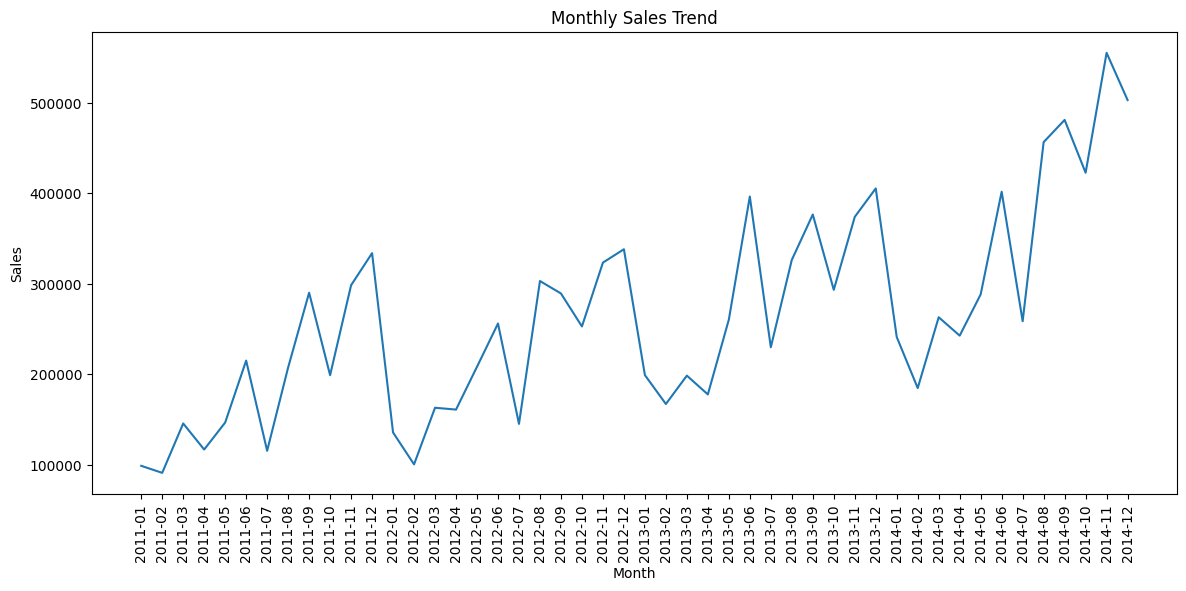

In [ ]:
plt.figure(figsize=(14,6))

plt.plot(monthly_sales.index, monthly_sales.values)

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales")

plt.xticks(rotation=90)

plt.show()

### Business Question 4:
Which product categories generate the highest revenue?

In [ ]:
category_sales = (
    df
    .groupby('category')['sales']
    .sum()
    .sort_values(ascending=False)
)

category_sales

,sales
category,
Technology,4744691
Furniture,4110884
Office Supplies,3787330


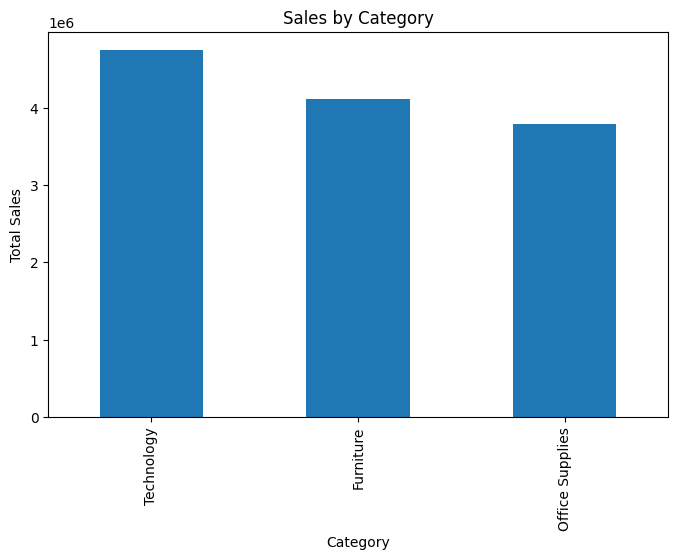

In [ ]:
plt.figure(figsize=(8,5))

category_sales.plot(kind='bar')

plt.title("Sales by Category")
plt.xlabel("Category")
plt.ylabel("Total Sales")

plt.show()

### Business Question 5:
Which regions contribute most to total sales?

In [ ]:
region_sales = (
    df
    .groupby('region')['sales']
    .sum()
    .sort_values(ascending=False)
)

region_sales.head(10)

,sales
region,
Central,2822399
South,1600960
North,1248192
Oceania,1100207
Southeast Asia,884438
North Asia,848349
EMEA,806184
Africa,783776
Central Asia,752839


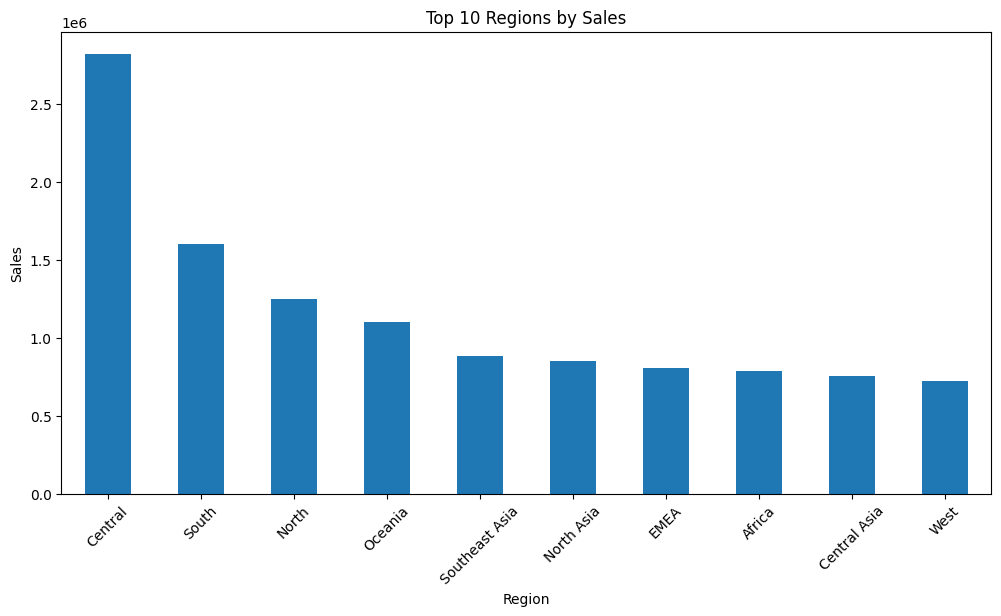

In [ ]:
plt.figure(figsize=(12,6))

region_sales.head(10).plot(kind='bar')

plt.title("Top 10 Regions by Sales")
plt.xlabel("Region")
plt.ylabel("Sales")

plt.xticks(rotation=45)

plt.show()

Which product categories generate the highest profit?

In [ ]:
category_profit = (
    df
    .groupby('category')['profit']
    .sum()
    .sort_values(ascending=False)
)

print(category_profit)

category
Technology         663778.73318
Office Supplies    518473.83430
Furniture          285204.72380
Name: profit, dtype: float64


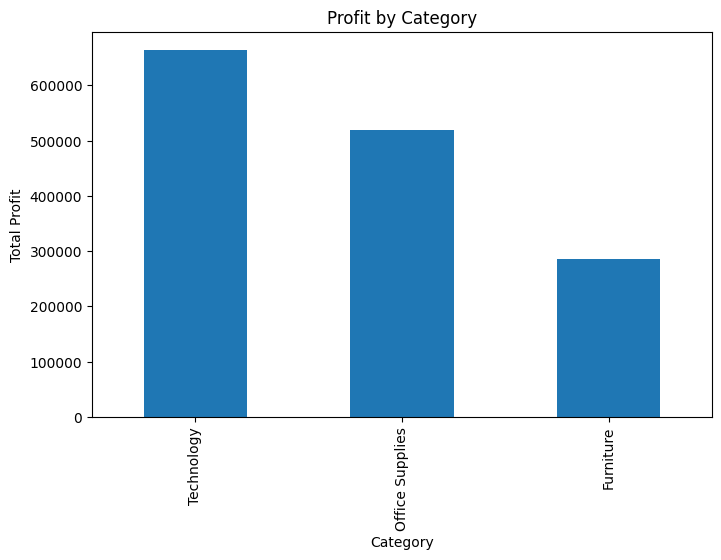

In [ ]:
plt.figure(figsize=(8,5))

category_profit.plot(kind='bar')

plt.title("Profit by Category")
plt.xlabel("Category")
plt.ylabel("Total Profit")

plt.show()

Which customers contribute the most revenue?

In [ ]:
top_customers = (
    df
    .groupby('customer_name')['sales']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

print(top_customers)

customer_name
Tom Ashbrook          40489
Tamara Chand          37453
Greg Tran             35552
Christopher Conant    35187
Sean Miller           35170
Bart Watters          32315
Natalie Fritzler      31778
Fred Hopkins          30404
Jane Waco             30288
Hunter Lopez          30246
Name: sales, dtype: int64


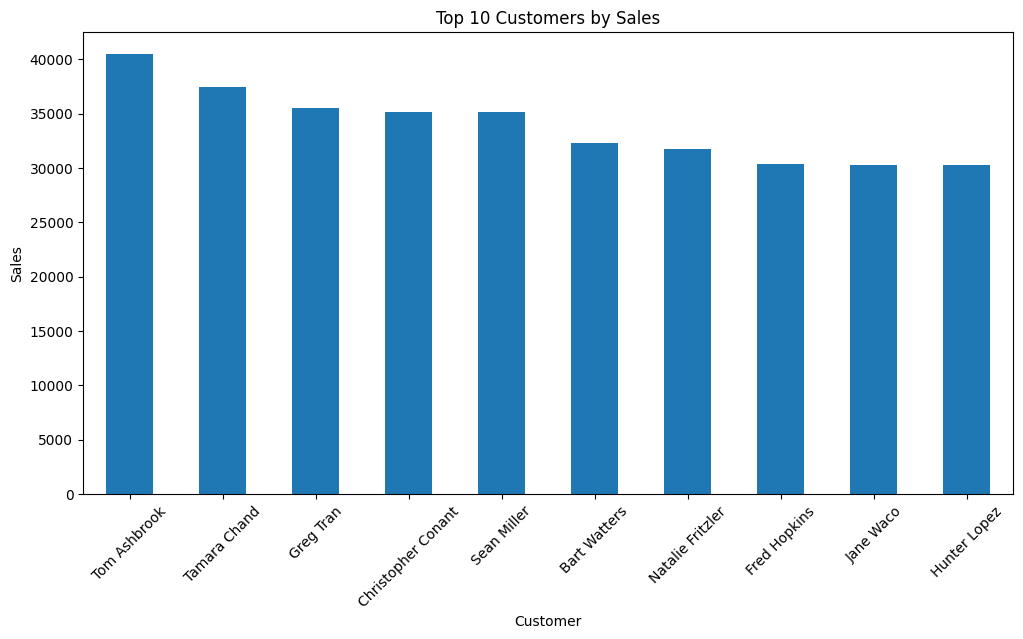

In [ ]:
plt.figure(figsize=(12,6))

top_customers.plot(kind='bar')

plt.title("Top 10 Customers by Sales")
plt.xlabel("Customer")
plt.ylabel("Sales")

plt.xticks(rotation=45)

plt.show()

Which customer segment generates the highest revenue?

In [ ]:
segment_sales = (
    df
    .groupby('segment')['sales']
    .sum()
    .sort_values(ascending=False)
)

print(segment_sales)

segment
Consumer       6508141
Corporate      3824808
Home Office    2309956
Name: sales, dtype: int64


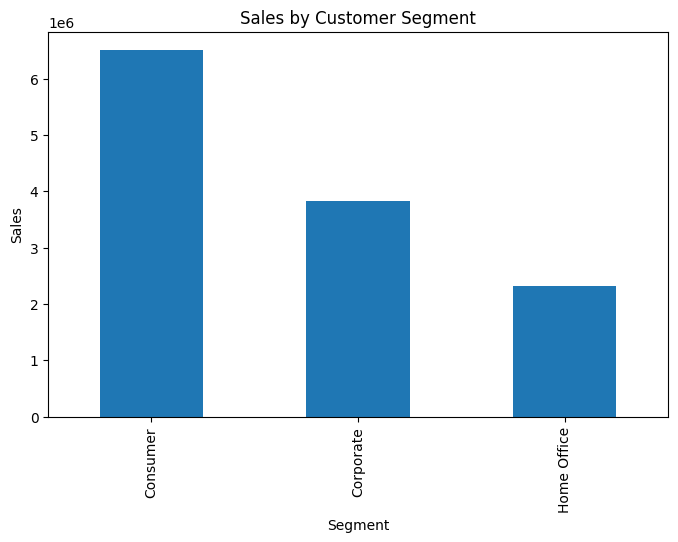

In [ ]:
plt.figure(figsize=(8,5))

segment_sales.plot(kind='bar')

plt.title("Sales by Customer Segment")
plt.xlabel("Segment")
plt.ylabel("Sales")

plt.show()

In [ ]:
How do discounts affect profitability?

In [ ]:
correlation = df['discount'].corr(df['profit'])

print(f"Correlation between Discount and Profit: {correlation:.3f}")

Correlation between Discount and Profit: -0.316


# Day 4: Exploratory Data Analysis Completed

## Key Findings

- Total Revenue: $12.64M
- Total Profit: $1.47M
- Technology is the most profitable category.
- Consumer customers generate the highest sales.
- The Central region contributes the highest revenue.
- Discounts negatively affect profitability (-0.316 correlation).

## Strategic Recommendations

- Invest more in Technology products.
- Develop loyalty programs for top customers.
- Optimize discount strategies.
- Strengthen the Consumer and Corporate segments.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
df = pd.read_csv(
    '/content/drive/MyDrive/Retail-Sales-Performance-Analytics-and-Forecasting/data/processed/superstore_clean.csv',
    parse_dates=['order_date', 'ship_date']
)

print(df.shape)

(51290, 26)


How much revenue was generated each month?

In [ ]:
monthly_sales = (
    df
    .groupby(pd.Grouper(key='order_date', freq='M'))['sales']
    .sum()
    .reset_index()
)

monthly_sales.head()

/tmp/ipykernel_17105/1120401139.py:3: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  .groupby(pd.Grouper(key='order_date', freq='M'))['sales']


,order_date,sales
0,2011-01-31,98902
1,2011-02-28,91152
2,2011-03-31,145726
3,2011-04-30,116927
4,2011-05-31,146762


In [ ]:
print("Start Date:", monthly_sales['order_date'].min())
print("End Date:", monthly_sales['order_date'].max())
print("Total Months:", len(monthly_sales))

Start Date: 2011-01-31 00:00:00
End Date: 2014-12-31 00:00:00
Total Months: 48


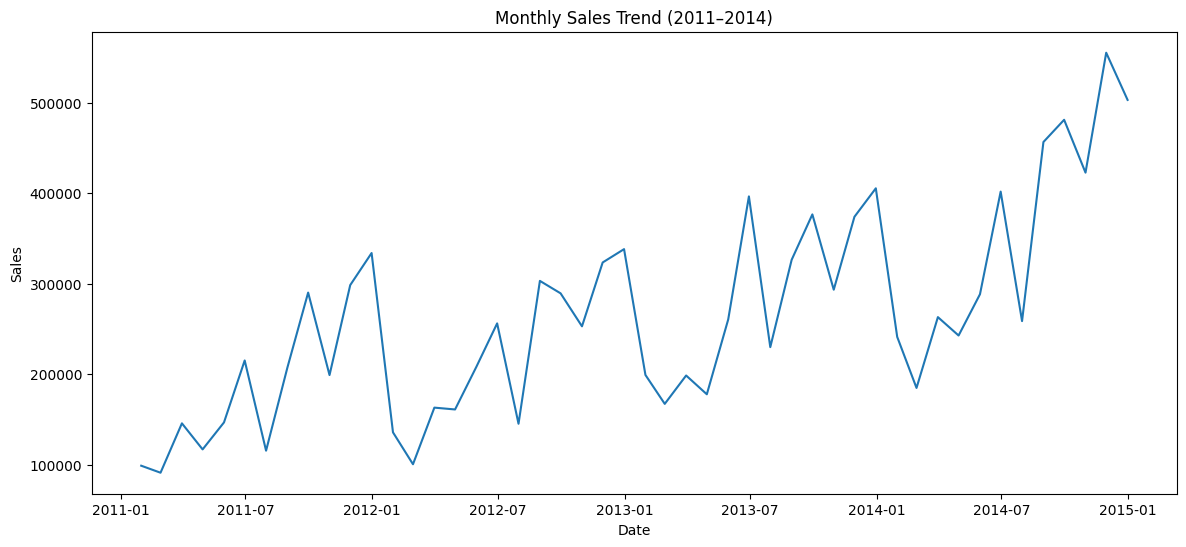

In [ ]:
plt.figure(figsize=(14,6))

plt.plot(
    monthly_sales['order_date'],
    monthly_sales['sales']
)

plt.title("Monthly Sales Trend (2011–2014)")
plt.xlabel("Date")
plt.ylabel("Sales")

plt.show()

In [ ]:
monthly_sales['year'] = monthly_sales['order_date'].dt.year
monthly_sales['month'] = monthly_sales['order_date'].dt.month

monthly_sales.head()

,order_date,sales,year,month
0,2011-01-31,98902,2011,1
1,2011-02-28,91152,2011,2
2,2011-03-31,145726,2011,3
3,2011-04-30,116927,2011,4
4,2011-05-31,146762,2011,5


In [ ]:
seasonality = (
    monthly_sales
    .groupby('month')['sales']
    .mean()
)

print(seasonality)

month
1     168785.25
2     135942.00
3     192629.75
4     174650.75
5     226015.25
6     317437.75
7     187355.75
8     323463.00
9     359358.00
10    292055.00
11    387829.75
12    395204.00
Name: sales, dtype: float64


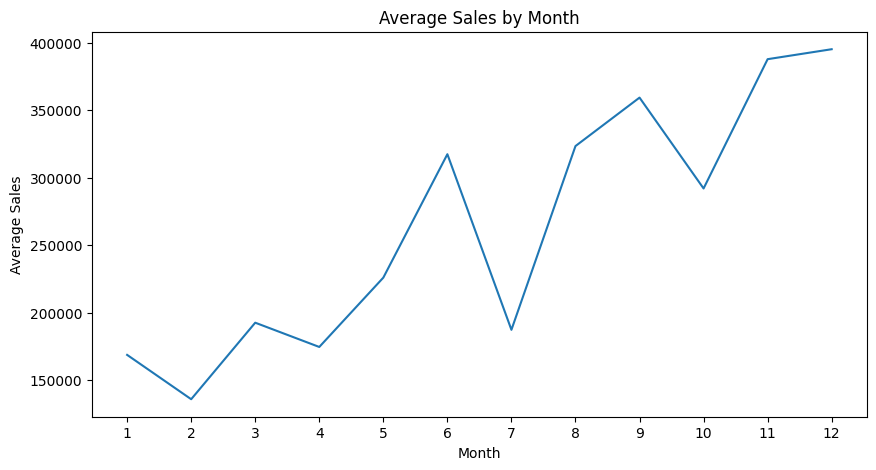

In [ ]:
plt.figure(figsize=(10,5))

seasonality.plot()

plt.title("Average Sales by Month")
plt.xlabel("Month")
plt.ylabel("Average Sales")

plt.xticks(range(1,13))

plt.show()

In [ ]:
train = monthly_sales.iloc[:-6]
test = monthly_sales.iloc[-6:]

print("Train Shape:", train.shape)
print("Test Shape:", test.shape)

Train Shape: (42, 4)
Test Shape: (6, 4)


In [ ]:
monthly_sales.to_csv(
    '/content/drive/MyDrive/Retail-Sales-Performance-Analytics-and-Forecasting/data/processed/monthly_sales.csv',
    index=False
)

print("✅ Monthly sales dataset saved!")

✅ Monthly sales dataset saved!


Sales exhibit strong seasonality, with peak performance occurring in November and December. This pattern suggests significant holiday-driven demand and highlights the importance of inventory and marketing preparation during Q4.

In [ ]:
!pip install statsmodels

In [ ]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error
import numpy as np

In [ ]:
train_sales = train['sales']
test_sales = test['sales']

In [ ]:
model = SARIMAX(
    train_sales,
    order=(1,1,1),
    seasonal_order=(1,1,1,12)
)

results = model.fit()

print(results.summary())

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'


                                     SARIMAX Results                                      
Dep. Variable:                              sales   No. Observations:                   42
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 12)   Log Likelihood                -344.183
Date:                            Sun, 28 Jun 2026   AIC                            698.367
Time:                                    22:18:44   BIC                            705.203
Sample:                                         0   HQIC                           700.508
                                             - 42                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.6970      0.183      3.813      0.000       0.339       1.055
ma.L1         -0.8826      0.177   

In [ ]:
forecast = results.forecast(steps=6)

print(forecast)

42    254011.309408
43    370166.136446
44    396586.584832
45    332720.631424
46    406421.804272
47    431682.753872
Name: predicted_mean, dtype: float64


In [ ]:
mae = mean_absolute_error(test_sales, forecast)

print(f"MAE: {mae:,.2f}")

MAE: 81,033.13


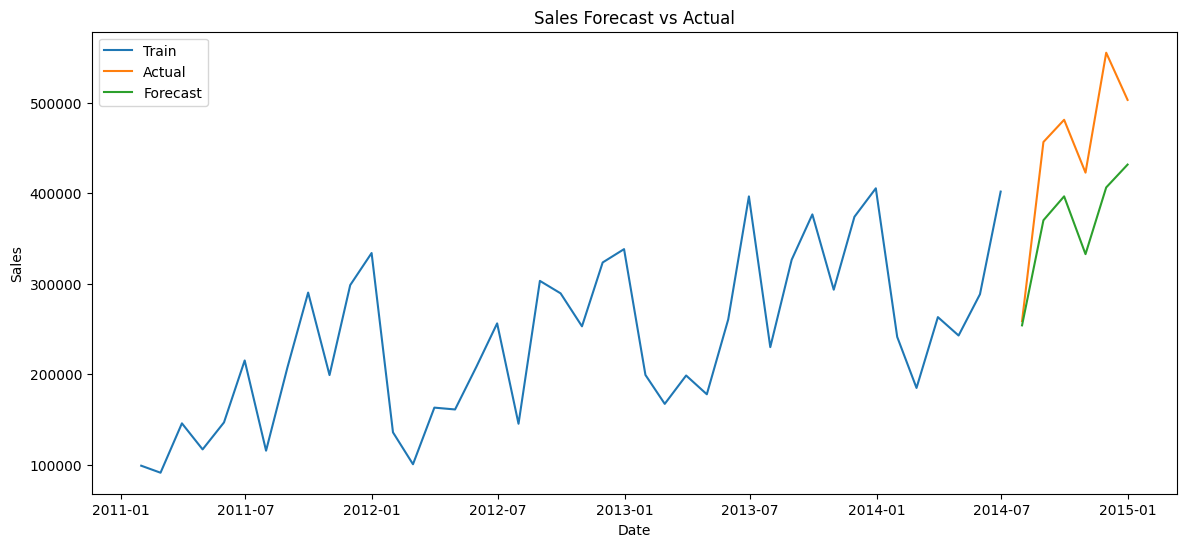

In [ ]:
plt.figure(figsize=(14,6))

plt.plot(
    train['order_date'],
    train_sales,
    label='Train'
)

plt.plot(
    test['order_date'],
    test_sales,
    label='Actual'
)

plt.plot(
    test['order_date'],
    forecast,
    label='Forecast'
)

plt.title("Sales Forecast vs Actual")
plt.xlabel("Date")
plt.ylabel("Sales")

plt.legend()

plt.show()

# Day 5: Sales Forecasting Completed

## Model Used
- SARIMA (1,1,1)(1,1,1,12)

## Model Performance
- MAE: 81,033
- Average Monthly Sales: 263,394
- Error Rate: ~31%

## Key Findings
- The model successfully captures long-term growth trends.
- Strong seasonal effects are visible, especially during Q4.
- November and December consistently generate the highest sales.
- Forecast accuracy is acceptable for strategic business planning.

## Business Recommendations
- Increase inventory before Q4 demand peaks.
- Allocate additional marketing budget for November and December.
- Continue monitoring discount strategies to protect profitability.

In [ ]:
full_sales = monthly_sales['sales']

full_model = SARIMAX(
    full_sales,
    order=(1,1,1),
    seasonal_order=(1,1,1,12)
)

full_results = full_model.fit()

print("✅ Full model trained successfully!")

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'


✅ Full model trained successfully!


In [ ]:
future_forecast = full_results.forecast(steps=12)

print(future_forecast)

48    348223.231552
49    295672.618924
50    356476.451224
51    332617.286081
52    388904.721389
53    512730.078581
54    358958.858658
55    523909.327283
56    559869.968081
57    490732.552612
58    609504.595123
59    581755.738224
Name: predicted_mean, dtype: float64


In [ ]:
future_dates = pd.date_range(
    start='2015-01-31',
    periods=12,
    freq='M'
)

future_dates

/tmp/ipykernel_17105/1711891722.py:1: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  future_dates = pd.date_range(


DatetimeIndex(['2015-01-31', '2015-02-28', '2015-03-31', '2015-04-30',
               '2015-05-31', '2015-06-30', '2015-07-31', '2015-08-31',
               '2015-09-30', '2015-10-31', '2015-11-30', '2015-12-31'],
              dtype='datetime64[ns]', freq='ME')

In [ ]:
forecast_df = pd.DataFrame({
    'date': future_dates,
    'forecast_sales': future_forecast.values
})

forecast_df

,date,forecast_sales
0,2015-01-31,348223.231552
1,2015-02-28,295672.618924
2,2015-03-31,356476.451224
3,2015-04-30,332617.286081
4,2015-05-31,388904.721389
5,2015-06-30,512730.078581
6,2015-07-31,358958.858658
7,2015-08-31,523909.327283
8,2015-09-30,559869.968081
9,2015-10-31,490732.552612


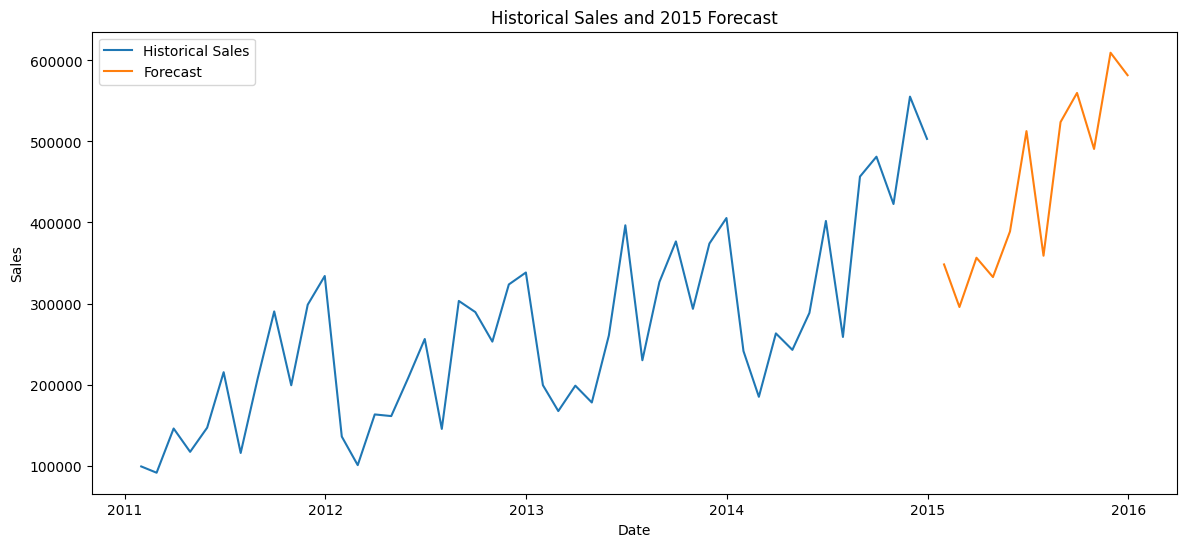

In [ ]:
plt.figure(figsize=(14,6))

plt.plot(
    monthly_sales['order_date'],
    monthly_sales['sales'],
    label='Historical Sales'
)

plt.plot(
    forecast_df['date'],
    forecast_df['forecast_sales'],
    label='Forecast'
)

plt.title("Historical Sales and 2015 Forecast")
plt.xlabel("Date")
plt.ylabel("Sales")

plt.legend()

plt.show()

In [ ]:
forecast_df.to_csv(
    '/content/drive/MyDrive/Retail-Sales-Performance-Analytics-and-Forecasting/data/processed/sales_forecast_2015.csv',
    index=False
)

print("✅ Forecast saved successfully!")

✅ Forecast saved successfully!


In [ ]:
category_performance = (
    df
    .groupby('category')
    .agg({
        'sales':'sum',
        'profit':'sum',
        'quantity':'sum'
    })
    .reset_index()
)

category_performance.to_csv(
    '/content/drive/MyDrive/Retail-Sales-Performance-Analytics-and-Forecasting/data/processed/category_performance.csv',
    index=False
)

In [ ]:
regional_performance = (
    df
    .groupby('region')
    .agg({
        'sales':'sum',
        'profit':'sum'
    })
    .reset_index()
)

regional_performance.to_csv(
    '/content/drive/MyDrive/Retail-Sales-Performance-Analytics-and-Forecasting/data/processed/regional_performance.csv',
    index=False
)

In [ ]:
segment_performance = (
    df
    .groupby('segment')
    .agg({
        'sales':'sum',
        'profit':'sum'
    })
    .reset_index()
)

segment_performance.to_csv(
    '/content/drive/MyDrive/Retail-Sales-Performance-Analytics-and-Forecasting/data/processed/segment_performance.csv',
    index=False
)

In [ ]:
forecast_df = pd.DataFrame({
    'date': future_dates,
    'forecast_sales': future_forecast.values
})

forecast_df

,date,forecast_sales
0,2015-01-31,348223.231552
1,2015-02-28,295672.618924
2,2015-03-31,356476.451224
3,2015-04-30,332617.286081
4,2015-05-31,388904.721389
5,2015-06-30,512730.078581
6,2015-07-31,358958.858658
7,2015-08-31,523909.327283
8,2015-09-30,559869.968081
9,2015-10-31,490732.552612


In [ ]:
forecast_df.head()

,date,forecast_sales
0,2015-01-31,348223.231552
1,2015-02-28,295672.618924
2,2015-03-31,356476.451224
3,2015-04-30,332617.286081
4,2015-05-31,388904.721389


In [ ]:
forecast_df.tail()

,date,forecast_sales
7,2015-08-31,523909.327283
8,2015-09-30,559869.968081
9,2015-10-31,490732.552612
10,2015-11-30,609504.595123
11,2015-12-31,581755.738224


In [ ]:
import os

os.listdir(
    '/content/drive/MyDrive/Retail-Sales-Performance-Analytics-and-Forecasting/data/processed'
)

['superstore_clean.csv',
 'monthly_sales.csv',
 'sales_forecast_2015.csv',
 'category_performance.csv',
 'regional_performance.csv',
 'segment_performance.csv']